In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('spam.csv')

In [3]:
data

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [5]:
data.describe()

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [7]:
X = TfidfVectorizer().fit_transform(data['Message']).toarray()

In [8]:
X.shape

(5572, 8709)

In [9]:
Y = data['Category'].map({'spam': 1, 'ham': 0})

In [10]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [11]:
Y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: Category, Length: 5572, dtype: int64

In [12]:
Y.shape

(5572,)

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.35)

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
lgr = LogisticRegression()
lgr.fit(x_train, y_train)

LogisticRegression()

In [17]:
y_pred = lgr.predict(x_test)

In [27]:
y_pred[:30]

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [19]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [20]:
accuracy_score(y_true=y_test, y_pred=y_pred)

0.9615581752947207

In [21]:
Y.sum()/Y.shape[0] * 100

np.float64(13.406317300789663)

In [22]:
y_test.sum()

np.int64(242)

In [23]:
y_pred.sum()

np.int64(167)

In [24]:
print(accuracy_score(y_true=y_test, y_pred=y_pred))
print(recall_score(y_true=y_test, y_pred=y_pred))
print(precision_score(y_true=y_test, y_pred=y_pred))
print(f1_score(y_true=y_test, y_pred=y_pred))


0.9615581752947207
0.6900826446280992
1.0
0.8166259168704156


In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

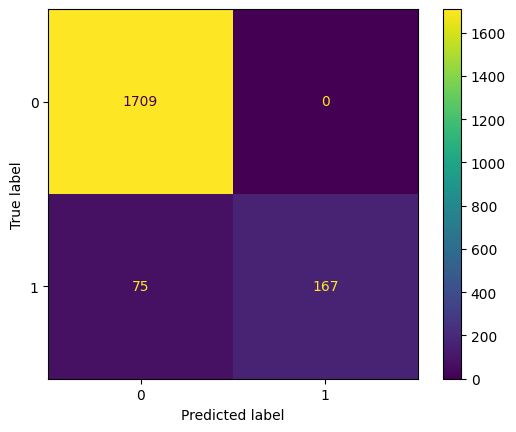

In [26]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_true=y_test, y_pred=y_pred))

disp.plot();